In [1]:
RANDOM_SEED = 42

import random
import numpy as np

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Seed установлен:", RANDOM_SEED)

Seed установлен: 42


In [2]:
import pandas as pd

ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

print("Ratings:", ratings.shape)
print("Movies:", movies.shape)

Ratings: (100836, 4)
Movies: (9742, 3)


In [3]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
print("Количество пользователей:",
      ratings['userId'].nunique())

print("Количество фильмов:",
      ratings['movieId'].nunique())

print("Количество оценок:",
      len(ratings))

Количество пользователей: 610
Количество фильмов: 9724
Количество оценок: 100836


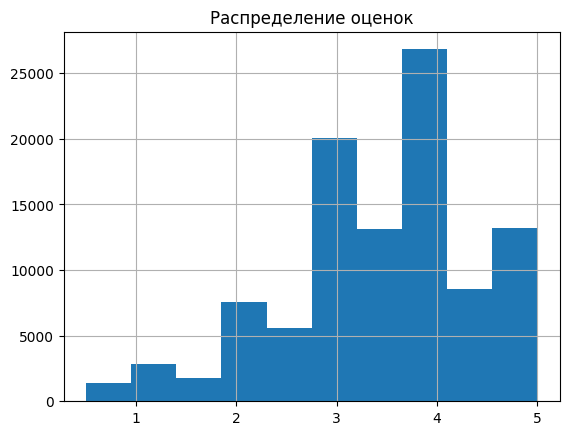

In [6]:
import matplotlib.pyplot as plt

ratings['rating'].hist(bins=10)

plt.title("Распределение оценок")
plt.show()

In [7]:
!pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 45.8 MB/s eta 0:00:00


In [8]:
from surprise import Dataset
from surprise import Reader

reader = Reader(rating_scale=(0.5, 5))

data = Dataset.load_from_df(
    ratings[['userId', 'movieId', 'rating']],
    reader
)

print("Данные готовы")

Данные готовы


In [9]:
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

In [10]:
from surprise import SVD

model = SVD(
    random_state=42
)

model.fit(trainset)

In [11]:
from surprise import accuracy

predictions = model.test(testset)

rmse = accuracy.rmse(predictions)

print("RMSE:", rmse)

RMSE: 0.8807
RMSE: 0.8807462819979623


In [12]:
from surprise import SVD
from surprise import accuracy

experiments = [
    {"n_factors": 50, "n_epochs": 20},
    {"n_factors": 100, "n_epochs": 30},
    {"n_factors": 150, "n_epochs": 50}
]

results = []

for params in experiments:

    model = SVD(
        n_factors=params["n_factors"],
        n_epochs=params["n_epochs"],
        random_state=42
    )

    model.fit(trainset)

    predictions = model.test(testset)

    rmse = accuracy.rmse(
        predictions,
        verbose=False
    )

    results.append({
        "n_factors": params["n_factors"],
        "n_epochs": params["n_epochs"],
        "rmse": rmse
    })

results

[{'n_factors': 50, 'n_epochs': 20, 'rmse': np.float64(0.8774680781839198)},
 {'n_factors': 100, 'n_epochs': 30, 'rmse': np.float64(0.8827945358061376)},
 {'n_factors': 150, 'n_epochs': 50, 'rmse': np.float64(0.8882770506564813)}]

In [13]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df

,n_factors,n_epochs,rmse
0,50,20,0.877468
1,100,30,0.882795
2,150,50,0.888277


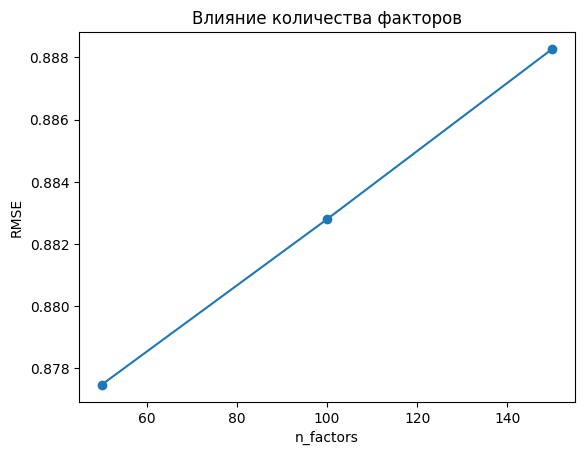

In [14]:
import matplotlib.pyplot as plt

plt.plot(
    results_df["n_factors"],
    results_df["rmse"],
    marker="o"
)

plt.xlabel("n_factors")
plt.ylabel("RMSE")
plt.title("Влияние количества факторов")

plt.show()

In [15]:
!pip install wandb

In [16]:
import wandb

wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 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


wandb: WARNING Invalid choice


wandb: Enter your choice: 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


wandb: WARNING Invalid choice


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: bystrukovaanastasia (bystrukovaanastasia-1mok) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [17]:
for params in experiments:

    run = wandb.init(
        project="movie-recommender",
        reinit=True
    )

    model = SVD(
        n_factors=params["n_factors"],
        n_epochs=params["n_epochs"],
        random_state=42
    )

    model.fit(trainset)

    predictions = model.test(testset)

    rmse = accuracy.rmse(
        predictions,
        verbose=False
    )

    wandb.log({
        "n_factors": params["n_factors"],
        "n_epochs": params["n_epochs"],
        "RMSE": rmse
    })

    run.finish()

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


RMSE,▁
n_epochs,▁
n_factors,▁
RMSE,0.87747
n_epochs,20
n_factors,50


RMSE,▁
n_epochs,▁
n_factors,▁
RMSE,0.88279
n_epochs,30
n_factors,100


RMSE,▁
n_epochs,▁
n_factors,▁
RMSE,0.88828
n_epochs,50
n_factors,150


In [18]:
results_df

,n_factors,n_epochs,rmse
0,50,20,0.877468
1,100,30,0.882795
2,150,50,0.888277


In [19]:
best_result = results_df.loc[
    results_df["rmse"].idxmin()
]

best_result

,0
n_factors,50.000000
n_epochs,20.000000
rmse,0.877468


In [20]:
best_model = SVD(
    n_factors=50,
    n_epochs=20,
    random_state=42
)

best_model.fit(trainset)

print("Лучшая модель обучена")

Лучшая модель обучена


In [21]:
import joblib

joblib.dump(
    best_model,
    "best_model.pkl"
)

print("Модель сохранена")

Модель сохранена


In [22]:
loaded_model = joblib.load(
    "best_model.pkl"
)

prediction = loaded_model.predict(
    uid=1,
    iid=50
)

print("Предсказанная оценка:")
print(round(prediction.est, 2))

Предсказанная оценка:
4.98


In [23]:
user_id = 1

movie_ids = ratings["movieId"].unique()

recommendations = []

for movie_id in movie_ids:

    pred = loaded_model.predict(
        user_id,
        movie_id
    )

    recommendations.append(
        (movie_id, pred.est)
    )

recommendations = sorted(
    recommendations,
    key=lambda x: x[1],
    reverse=True
)

In [24]:
top10 = recommendations[:10]

top10

[(np.int64(356), 5),
 (np.int64(527), 5),
 (np.int64(2329), 5),
 (np.int64(2959), 5),
 (np.int64(318), 5),
 (np.int64(2324), 5),
 (np.int64(3275), 5),
 (np.int64(38061), 5),
 (np.int64(2160), 5),
 (np.int64(741), 5)]

In [25]:
for movie_id, score in top10:

    title = movies[
        movies["movieId"] == movie_id
    ]["title"].values[0]

    print(
        f"{title} | прогноз: {score:.2f}"
    )

Forrest Gump (1994) | прогноз: 5.00
Schindler's List (1993) | прогноз: 5.00
American History X (1998) | прогноз: 5.00
Fight Club (1999) | прогноз: 5.00
Shawshank Redemption, The (1994) | прогноз: 5.00
Life Is Beautiful (La Vita è bella) (1997) | прогноз: 5.00
Boondock Saints, The (2000) | прогноз: 5.00
Kiss Kiss Bang Bang (2005) | прогноз: 5.00
Rosemary's Baby (1968) | прогноз: 5.00
Ghost in the Shell (Kôkaku kidôtai) (1995) | прогноз: 5.00


In [26]:
scores = [score for _, score in recommendations]

print("Максимум:", max(scores))
print("Минимум:", min(scores))

Максимум: 5
Минимум: 2.6650673315466578


In [27]:
recommendations[:20]

[(np.int64(356), 5),
 (np.int64(527), 5),
 (np.int64(2329), 5),
 (np.int64(2959), 5),
 (np.int64(318), 5),
 (np.int64(2324), 5),
 (np.int64(3275), 5),
 (np.int64(38061), 5),
 (np.int64(2160), 5),
 (np.int64(741), 5),
 (np.int64(1204), 5),
 (np.int64(1172), 5),
 (np.int64(4973), np.float64(4.987584328377739)),
 (np.int64(48516), np.float64(4.981133891668627)),
 (np.int64(1199), np.float64(4.981076125819158)),
 (np.int64(50), np.float64(4.9773903216754585)),
 (np.int64(1288), np.float64(4.974352644164015)),
 (np.int64(4011), np.float64(4.9726673983532335)),
 (np.int64(260), np.float64(4.96902108778627)),
 (np.int64(6016), np.float64(4.961964138163937))]

In [28]:
user_id = 1

user_movies = ratings[
    ratings["userId"] == user_id
]["movieId"].tolist()

print("Пользователь уже оценил:",
      len(user_movies),
      "фильмов")

Пользователь уже оценил: 232 фильмов


In [29]:
356 in user_movies

True

In [30]:
user_id = 1

user_movies = ratings[
    ratings["userId"] == user_id
]["movieId"].tolist()

recommendations = []

for movie_id in ratings["movieId"].unique():

    if movie_id not in user_movies:

        pred = loaded_model.predict(
            user_id,
            movie_id
        )

        recommendations.append(
            (movie_id, pred.est)
        )

recommendations = sorted(
    recommendations,
    key=lambda x: x[1],
    reverse=True
)

In [31]:
top10 = recommendations[:10]

In [32]:
for movie_id, score in top10:

    title = movies[
        movies["movieId"] == movie_id
    ]["title"].values[0]

    print(
        f"{title} | прогноз: {score:.3f}"
    )

Shawshank Redemption, The (1994) | прогноз: 5.000
Life Is Beautiful (La Vita è bella) (1997) | прогноз: 5.000
Boondock Saints, The (2000) | прогноз: 5.000
Kiss Kiss Bang Bang (2005) | прогноз: 5.000
Rosemary's Baby (1968) | прогноз: 5.000
Ghost in the Shell (Kôkaku kidôtai) (1995) | прогноз: 5.000
Lawrence of Arabia (1962) | прогноз: 5.000
Cinema Paradiso (Nuovo cinema Paradiso) (1989) | прогноз: 5.000
Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001) | прогноз: 4.988
Departed, The (2006) | прогноз: 4.981
